## Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Data

In [2]:
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (12000, 23)
Testing Features  : (3000, 23)
Training Labels   : (12000,)
Testing Labels    : (3000,)


## Calculate scale_pos_weight

In [3]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 4.54


In [5]:
param_grid = {

    "n_estimators": [200, 300, 400, 500],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.1, 0.5],

    "reg_lambda": [1, 2, 5]

}

print("Parameter grid created successfully.")

Parameter grid created successfully.


## Create the Base Model

In [6]:
# Base XGBoost model
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

print("✅ Base XGBoost model created.")

✅ Base XGBoost model created.


## Step 2: Hyperparameter Optimization

RandomizedSearchCV randomly samples parameter combinations from the predefined search space.

Compared to GridSearchCV, it is computationally efficient while still finding high-performing parameter combinations.

The model is evaluated using 5-fold cross-validation with the F1-score as the optimization metric because our primary goal is to improve denial detection.

In [7]:
# Randomized Hyperparameter Search
random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=100,

    scoring="f1",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

print("✅ RandomizedSearchCV created successfully.")

✅ RandomizedSearchCV created successfully.


## Train the Optimizer

In [8]:
# Start Hyperparameter Tuning
random_search.fit(X_train, y_train)

print("✅ Hyperparameter tuning completed.")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
✅ Hyperparameter tuning completed.


In [10]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
0.3900971171605932


## View the Best Parameters

In [11]:
# Best hyperparameters
print("Best Parameters:\n")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)

Best Parameters:

{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}

Best Cross-Validation F1 Score:
0.3900971171605932


## Get the Best Model

In [12]:
# Retrieve the best model
best_model = random_search.best_estimator_

print("✅ Best model extracted successfully.")

✅ Best model extracted successfully.


# Generate Predictions

In [13]:
# Generate predictions
y_pred_best = best_model.predict(X_test)

# Prediction probabilities
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


## Evaluate the Tuned Model

In [14]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.6797
Precision: 0.2999
Recall   : 0.5793
F1 Score : 0.3952
ROC-AUC  : 0.6895


In [15]:
print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_best
))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.70      0.78      2458
           1       0.30      0.58      0.40       542

    accuracy                           0.68      3000
   macro avg       0.59      0.64      0.59      3000
weighted avg       0.78      0.68      0.71      3000



## Confusion Matrix

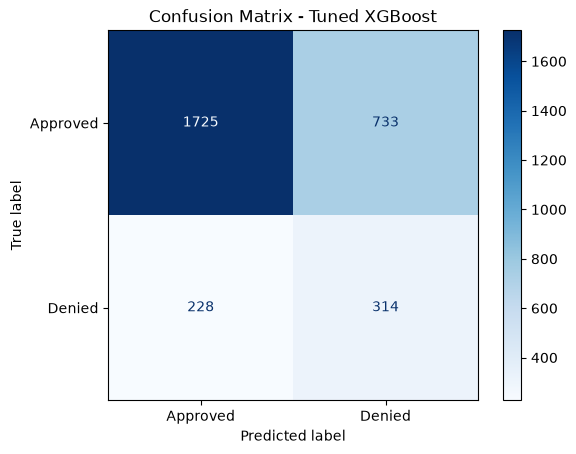

In [16]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved", "Denied"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Tuned XGBoost")

plt.show()

## Save the Tuned Model

In [18]:
joblib.dump(best_model, "tuned_xgboost_model.pkl")

print("✅ Tuned XGBoost model saved successfully.")

✅ Tuned XGBoost model saved successfully.


# Final Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|--------:|
| Baseline | 80.37 | 36.09 | 11.25 | 17.16 | 63.94 |
| Weighted | 72.03 | 26.83 | 31.73 | 29.08 | 61.35 |
| SMOTE | 76.00 | 26.82 | 19.00 | 22.25 | 58.17 |
| Tuned XGBoost | 67.97 | 29.99 | 57.93 | 39.52 | 68.95 |

The tuned XGBoost model was selected as the final model because it achieved the highest Recall, F1-score, and ROC-AUC, making it more suitable for healthcare claim denial prediction where identifying denied claims is the primary objective.

In [24]:
joblib.dump(best_model, "tuned_xgboost_model.pkl")

print("✅ Tuned model saved successfully.")

✅ Tuned model saved successfully.
